<a href="https://colab.research.google.com/github/abhayaqx1234/APS-Lab/blob/main/Lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2. Divide and Conquer (Sorting)

- **Created by Dr. Ajay

Write a python program to perform **Countingsort**.
* Statement:  Given a disordered list of repeated integers, rearrange the integers in natural order.
 Sample Input: [4,3,2,1,4,3,2,4,3,4]
 Sample Output: [1,2,2,3,3,3,4,4,4,4]

Time Complexity of Solution: Best Case O(n+k); Average Case O(n+k); Worst Case O(n+k), where n is the size of the input array and k means the values range from 0 to k.
- Approach:
Counting sort, like radix sort and bucket sort, is an integer based algorithm (i.e. the values of the input array are assumed to be integers). Hence counting sort is among the fastest sorting algorithms around, in theory. The  particular distinction for counting sort is that it creates a bucket for each value and keep a counter in each bucket. Then each time a value is encountered in the input collection, the appropriate counter is incremented. Because counting sort creates a bucket for each value, an imposing restriction is that the maximum value in the input array be known beforehand. Bucket sort uses a hash function to distribute values; counting sort, on the other hand, creates a counter for each value -- hence the name.
- Implementation notes:
1. Since the values range from 0 to k, create k+1 buckets.

2. To fill the buckets, iterate through the input list and
each time a value appears, increment the counter in its bucket.
3. Now fill the input list with the compressed data in the
buckets. Each bucket's key represents a value in the  array. So for each bucket, from smallest key to largest, add the index of the bucket to the input array and decrease the counter in said bucket by one; until the counter is zero.

Sample Input: [4, 3, 2, 1, 4, 3, 2, 4, 3, 4]
Sample Output: [1, 2, 2, 3, 3, 3, 4, 4, 4, 4]
Expected Output: [1, 2, 2, 3, 3, 3, 4, 4, 4, 4]


--- Benchmarking for k (max_val) = 50 ---
Size: 100, Time: 0.0207 ms
Size: 500, Time: 0.0649 ms
Size: 1000, Time: 0.1199 ms
Size: 2000, Time: 0.2440 ms
Size: 5000, Time: 0.6209 ms
Size: 10000, Time: 1.7412 ms
Size: 20000, Time: 2.5990 ms


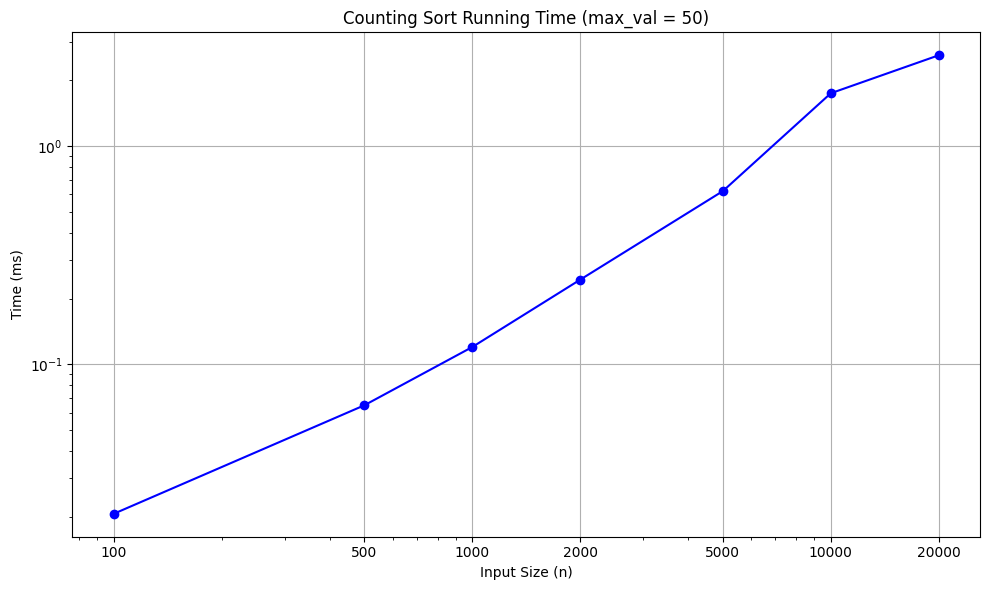


--- Benchmarking for k (max_val) = 100 ---
Size: 100, Time: 0.0438 ms
Size: 500, Time: 0.1149 ms
Size: 1000, Time: 0.1860 ms
Size: 2000, Time: 0.2414 ms
Size: 5000, Time: 0.6899 ms
Size: 10000, Time: 1.1712 ms
Size: 20000, Time: 2.3438 ms


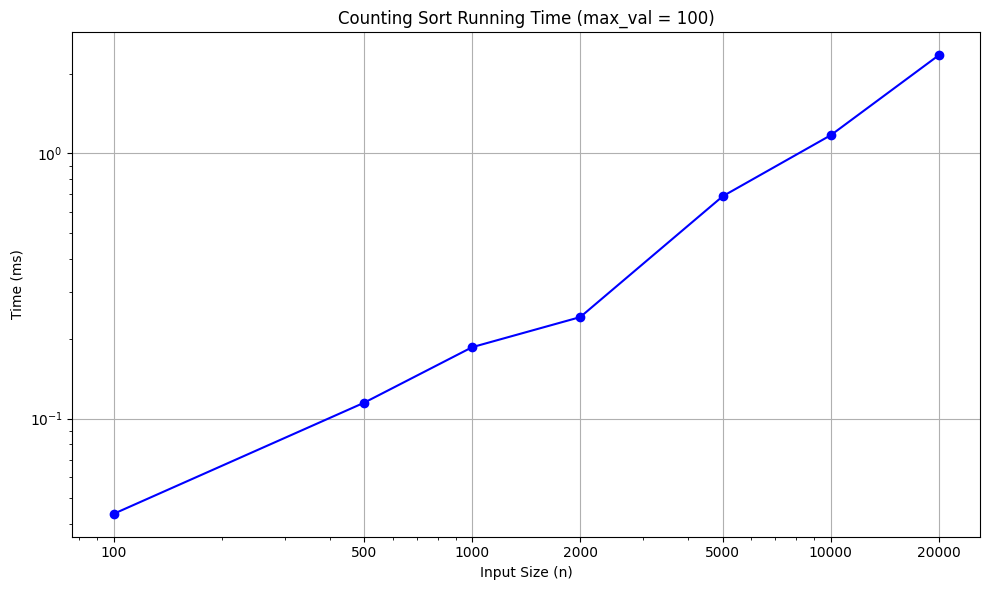


--- Benchmarking for k (max_val) = 500 ---
Size: 100, Time: 0.0800 ms
Size: 500, Time: 0.1786 ms
Size: 1000, Time: 0.3391 ms
Size: 2000, Time: 0.5874 ms
Size: 5000, Time: 1.4191 ms
Size: 10000, Time: 2.7554 ms
Size: 20000, Time: 5.5008 ms


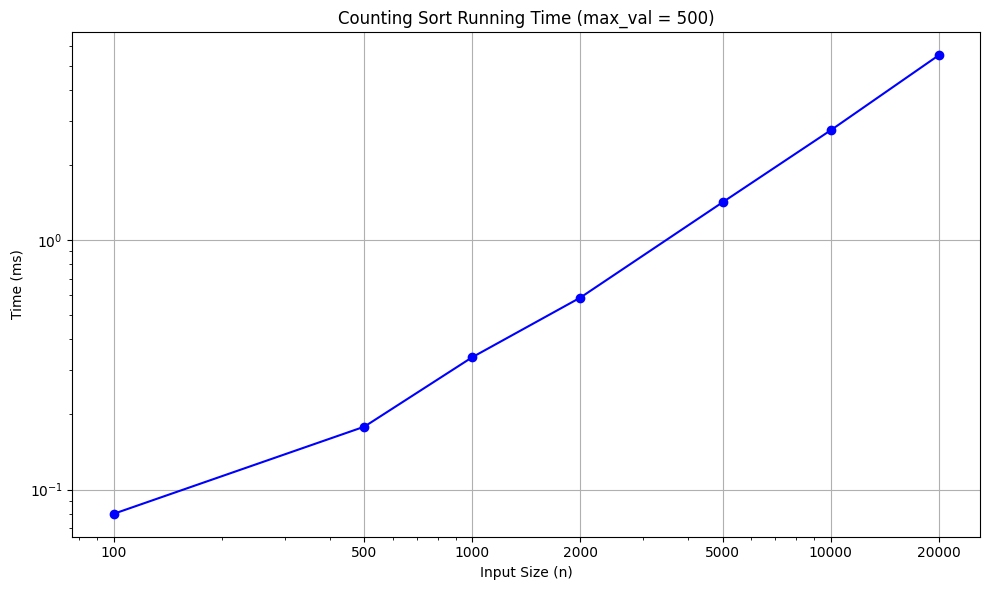


--- Benchmarking for k (max_val) = 1000 ---
Size: 100, Time: 0.0726 ms
Size: 500, Time: 0.1229 ms
Size: 1000, Time: 0.1929 ms
Size: 2000, Time: 0.3406 ms
Size: 5000, Time: 0.7841 ms
Size: 10000, Time: 1.4173 ms
Size: 20000, Time: 3.0448 ms


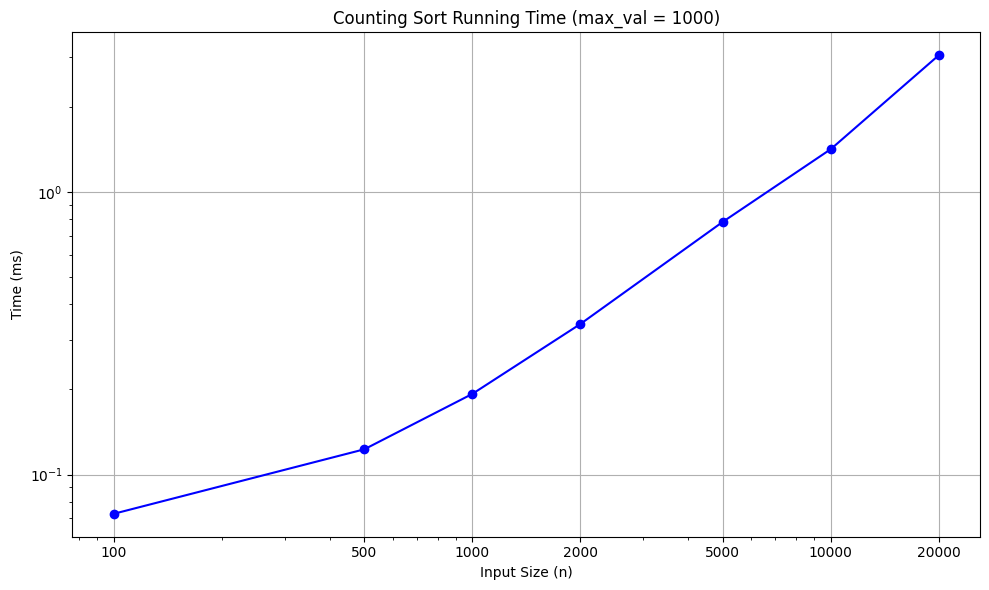

In [1]:
import time
import matplotlib.pyplot as plt
import random

def counting_sort(arr):
    if not arr:
        return []


    max_val = max(arr)
    min_val = min(arr)


    if min_val < 0:
        raise ValueError("Counting sort as implemented here expects non-negative integers.")


    count_array = [0] * (max_val + 1)


    for num in arr:
        count_array[num] += 1


    sorted_arr = []
    for i in range(max_val + 1):
        while count_array[i] > 0:
            sorted_arr.append(i)
            count_array[i] -= 1
    return sorted_arr

sample_input = [4, 3, 2, 1, 4, 3, 2, 4, 3, 4]
sample_output = counting_sort(sample_input.copy())

print(f"Sample Input: {sample_input}")
print(f"Sample Output: {sample_output}")
print(f"Expected Output: [1, 2, 2, 3, 3, 3, 4, 4, 4, 4]\n")



def generate_random_list(size, max_val):
    return [random.randint(0, max_val) for _ in range(size)]

sizes = [100, 500, 1000, 2000, 5000, 10000, 20000]
max_k_values = [50, 100, 500, 1000]

for k in max_k_values:
    runtimes = []
    print(f"\n--- Benchmarking for k (max_val) = {k} ---")
    for size in sizes:
        data = generate_random_list(size, k)
        start_time = time.perf_counter()
        counting_sort(data)
        end_time = time.perf_counter()
        duration = (end_time - start_time) * 1000 # in milliseconds
        runtimes.append(duration)
        print(f"Size: {size}, Time: {duration:.4f} ms")


    plt.figure(figsize=(10, 6))
    plt.plot(sizes, runtimes, marker='o', linestyle='-', color='b')
    plt.title(f'Counting Sort Running Time (max_val = {k})')
    plt.xlabel('Input Size (n)')
    plt.ylabel('Time (ms)')
    plt.grid(True)
    plt.xscale('log')
    plt.yscale('log')
    plt.xticks(sizes, labels=[str(s) for s in sizes]) # Ensure all x-ticks are visible
    plt.tight_layout()
    plt.show()


 - *Bucketsort*
Statement:
Given a disordered list of integers, rearrange them in natural order.
 Sample Input: [8,5,3,1,9,6,0,7,4,2,5]
 Sample Output: [0,1,2,3,4,5,6,7,8,9,5]
Time Complexity of Solution:
Best Case O(n); Average Case O(n); Worst Case O(n).
- Approach:
If it sounds too good to be true, then most likely it's not true. Bucketsort is not an exception to this adage. For bucketsort to
work at its blazing efficiency, there are multiple prerequisites.
First the hash function that is used to partition the elements need
to be very good and must produce ordered hash: if i < k then
hash(i) < hash(k). Second, the elements to be sorted must be
uniformly distributed.
  The aforementioned aside, bucket sort is actually very good
considering that counting sort is reasonably speaking its upper
bound. And counting sort is very fast. The particular distinction
for bucket sort is that it uses a hash function to partition the
keys of the input array, so that multiple keys may hash to the same
bucket. Hence each bucket must effectively be a growable list;
similar to radix sort.


Sample Input: [8, 5, 3, 1, 9, 6, 0, 7, 4, 2, 5]
Sample Output: [0, 1, 2, 3, 4, 5, 5, 6, 7, 8, 9]
Expected Output: [0, 1, 2, 3, 4, 5, 5, 6, 7, 8, 9]


--- Benchmarking Bucket Sort for max_val = 50 ---
Size: 100, Time: 0.0799 ms
Size: 500, Time: 0.9240 ms
Size: 1000, Time: 4.2257 ms
Size: 2000, Time: 16.9205 ms
Size: 5000, Time: 136.0984 ms
Size: 10000, Time: 473.3578 ms
Size: 20000, Time: 1943.3635 ms


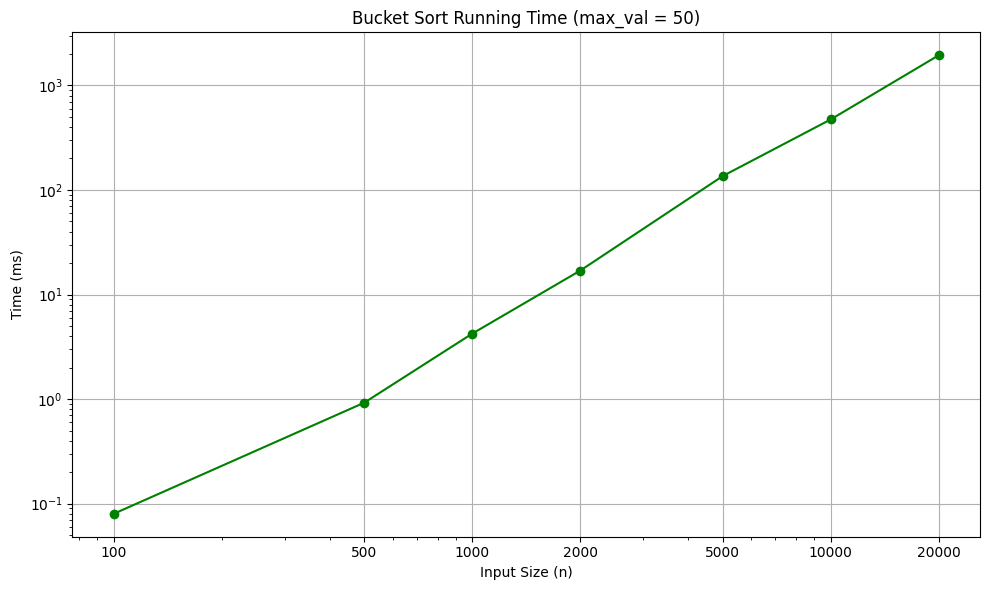


--- Benchmarking Bucket Sort for max_val = 100 ---
Size: 100, Time: 0.0646 ms
Size: 500, Time: 0.6577 ms
Size: 1000, Time: 1.9348 ms
Size: 2000, Time: 7.5285 ms
Size: 5000, Time: 75.9909 ms
Size: 10000, Time: 237.6873 ms
Size: 20000, Time: 988.6416 ms


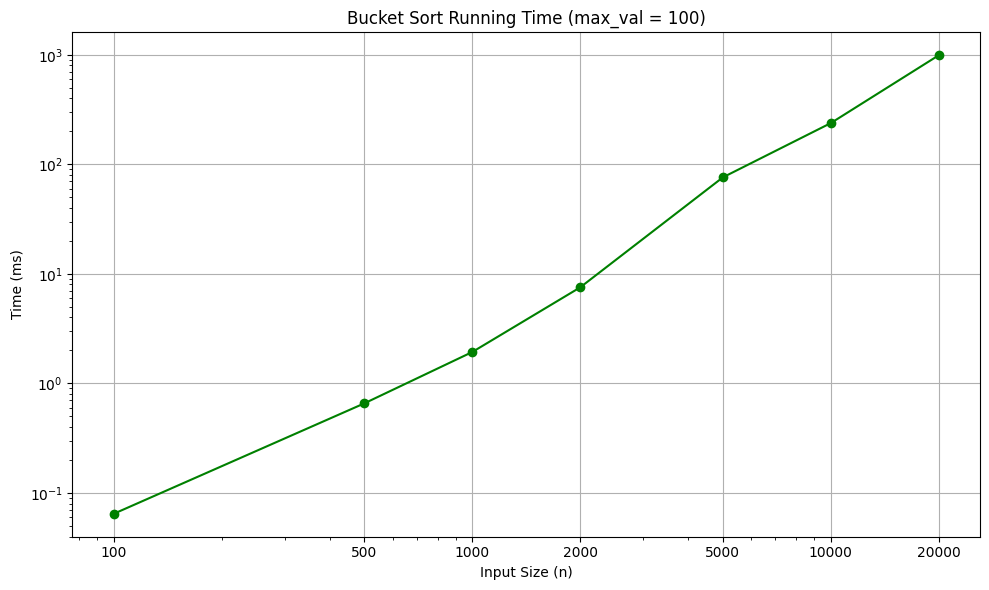


--- Benchmarking Bucket Sort for max_val = 500 ---
Size: 100, Time: 0.1127 ms
Size: 500, Time: 0.3087 ms
Size: 1000, Time: 0.7714 ms
Size: 2000, Time: 2.4499 ms
Size: 5000, Time: 10.6439 ms
Size: 10000, Time: 43.0035 ms
Size: 20000, Time: 183.8417 ms


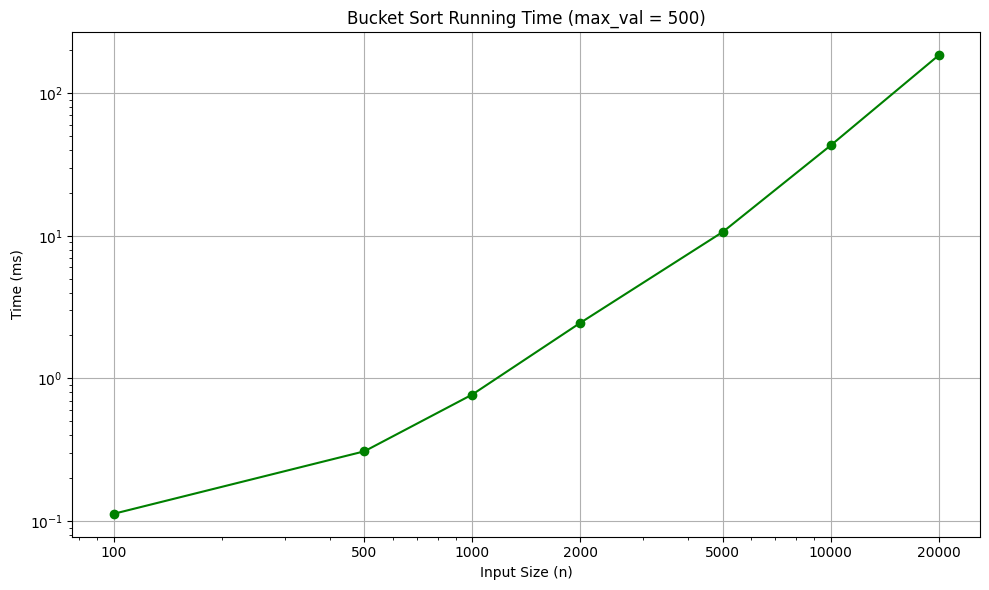


--- Benchmarking Bucket Sort for max_val = 1000 ---
Size: 100, Time: 0.0900 ms
Size: 500, Time: 0.2852 ms
Size: 1000, Time: 0.5842 ms
Size: 2000, Time: 1.4990 ms
Size: 5000, Time: 6.3693 ms
Size: 10000, Time: 28.2371 ms
Size: 20000, Time: 77.4220 ms


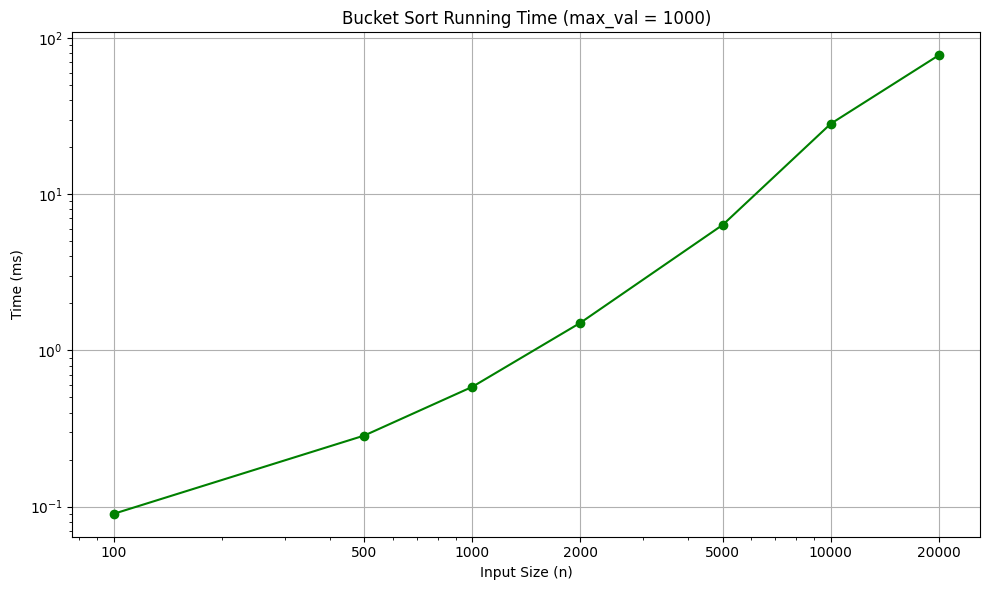

In [2]:
import time
import matplotlib.pyplot as plt
import random

def insertion_sort(arr):
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1
        while j >= 0 and key < arr[j]:
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = key

def bucket_sort(arr):
    if not arr:
        return []

    max_val = max(arr)
    min_val = min(arr)

    if min_val < 0:
        offset = abs(min_val)
        arr = [x + offset for x in arr]
        max_val = max(arr)
    else:
        offset = 0

    num_buckets = 10
    if max_val == 0:
        num_buckets = 1
    else:
        num_buckets = max(1, max_val // num_buckets)

    buckets = [[] for _ in range(num_buckets)]

    for num in arr:
        if max_val == 0:
            bucket_index = 0
        else:
            bucket_index = min(num // (max_val // num_buckets + 1), num_buckets - 1)
        buckets[bucket_index].append(num)

    sorted_arr = []
    for bucket in buckets:
        insertion_sort(bucket)
        sorted_arr.extend(bucket)

    if offset > 0:
        sorted_arr = [x - offset for x in sorted_arr]

    return sorted_arr

sample_input_bucket = [8, 5, 3, 1, 9, 6, 0, 7, 4, 2, 5]
sample_output_bucket = bucket_sort(sample_input_bucket.copy())

print(f"Sample Input: {sample_input_bucket}")
print(f"Sample Output: {sample_output_bucket}")
print(f"Expected Output: [0, 1, 2, 3, 4, 5, 5, 6, 7, 8, 9]\n")

def generate_random_list_bucket(size, max_val):
    return [random.randint(0, max_val) for _ in range(size)]

sizes = [100, 500, 1000, 2000, 5000, 10000, 20000]
max_vals_bucket = [50, 100, 500, 1000]

for k in max_vals_bucket:
    runtimes = []
    print(f"\n--- Benchmarking Bucket Sort for max_val = {k} ---")
    for size in sizes:
        data = generate_random_list_bucket(size, k)
        start_time = time.perf_counter()
        bucket_sort(data)
        end_time = time.perf_counter()
        duration = (end_time - start_time) * 1000
        runtimes.append(duration)
        print(f"Size: {size}, Time: {duration:.4f} ms")

    plt.figure(figsize=(10, 6))
    plt.plot(sizes, runtimes, marker='o', linestyle='-', color='g')
    plt.title(f'Bucket Sort Running Time (max_val = {k})')
    plt.xlabel('Input Size (n)')
    plt.ylabel('Time (ms)')
    plt.grid(True)
    plt.xscale('log')
    plt.yscale('log')
    plt.xticks(sizes, labels=[str(s) for s in sizes])
    plt.tight_layout()
    plt.show()


**Radix sort**
Statement:Given a disordered list of integers, rearrange them in natural order.
Sample Input: [18,5,100,3,1,19,6,0,7,4,2]
Sample Output: [0,1,2,3,4,5,6,7,18,19,100]
Time Complexity of Solution:Best Case O(kn); Average Case O(kn); Worst Case O(kn),where k is the length of the longest number and n is the size of the input array.Note: if k is greater than log(n) then an nlog(n) algorithm would be a better fit. In reality we can always change the radix to make k less than log(n).
- Approach: radix sort, like counting sort and bucket sort, is an integer based algorithm (i.e. the values of the input array are assumed to be integers). Hence radix sort is among the fastest sorting algorithms around, in theory. The particular distinction for radix sort is that it creates a bucket for each cipher (i.e. digit); as such, similar to bucket sort, each bucket in radix sort must be a
growable list that may admit different keys. For decimal values, the number of buckets is 10, as the decimal system has 10 numerals/cyphers (i.e. 0,1,2,3,4,5,6,7,8,9). Then the keys are continuously sorted by significant digits.

Sample Input: [18, 5, 100, 3, 1, 19, 6, 0, 7, 4, 2]
Sample Output: [0, 1, 2, 3, 4, 5, 6, 7, 18, 19, 100]
Expected Output: [0, 1, 2, 3, 4, 5, 6, 7, 18, 19, 100]


--- Benchmarking Radix Sort for max_val = 100 ---
Size: 100, Time: 0.0942 ms
Size: 500, Time: 0.8805 ms
Size: 1000, Time: 1.7798 ms
Size: 2000, Time: 3.5126 ms
Size: 5000, Time: 13.4512 ms
Size: 10000, Time: 29.4675 ms
Size: 20000, Time: 20.0961 ms


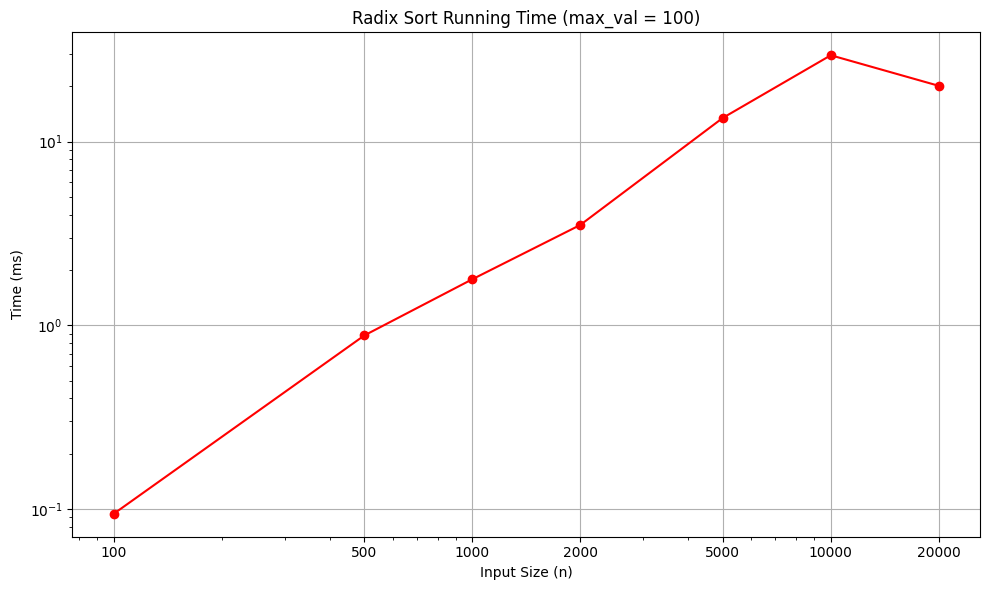


--- Benchmarking Radix Sort for max_val = 1000 ---
Size: 100, Time: 0.1059 ms
Size: 500, Time: 1.2187 ms
Size: 1000, Time: 1.2985 ms
Size: 2000, Time: 3.1019 ms
Size: 5000, Time: 8.3956 ms
Size: 10000, Time: 23.2694 ms
Size: 20000, Time: 32.5004 ms


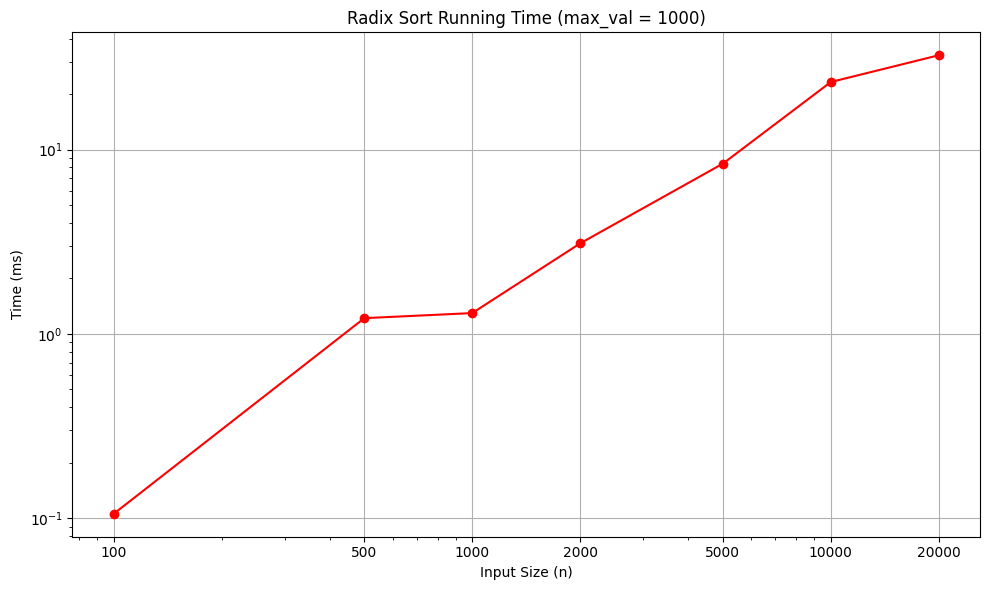


--- Benchmarking Radix Sort for max_val = 10000 ---
Size: 100, Time: 0.1340 ms
Size: 500, Time: 0.6878 ms
Size: 1000, Time: 1.3880 ms
Size: 2000, Time: 3.0169 ms
Size: 5000, Time: 7.0523 ms
Size: 10000, Time: 24.9710 ms
Size: 20000, Time: 31.6592 ms


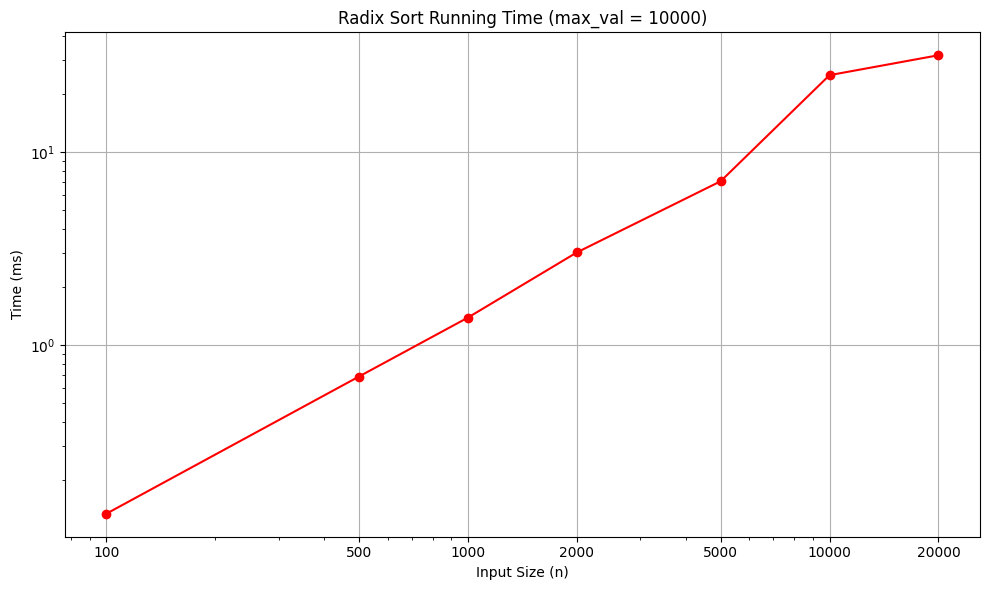


--- Benchmarking Radix Sort for max_val = 100000 ---
Size: 100, Time: 0.2018 ms
Size: 500, Time: 0.8916 ms
Size: 1000, Time: 1.6573 ms
Size: 2000, Time: 3.5977 ms
Size: 5000, Time: 9.3026 ms
Size: 10000, Time: 24.3901 ms
Size: 20000, Time: 38.1524 ms


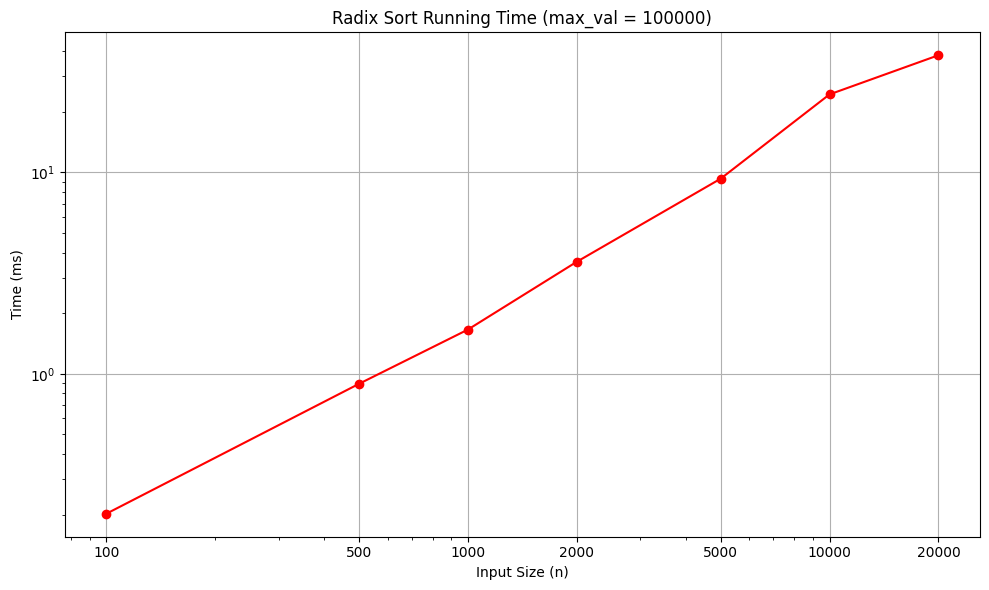

In [3]:
import time
import matplotlib.pyplot as plt
import random

def counting_sort_for_radix(arr, exp):
    n = len(arr)
    output = [0] * n
    count = [0] * 10

    for i in range(n):
        index = arr[i] // exp
        count[index % 10] += 1

    for i in range(1, 10):
        count[i] += count[i - 1]

    i = n - 1
    while i >= 0:
        index = arr[i] // exp
        output[count[index % 10] - 1] = arr[i]
        count[index % 10] -= 1
        i -= 1

    for i in range(n):
        arr[i] = output[i]

def radix_sort(arr):
    if not arr:
        return []

    max_val = max(arr)

    exp = 1
    while max_val // exp > 0:
        counting_sort_for_radix(arr, exp)
        exp *= 10
    return arr

sample_input_radix = [18, 5, 100, 3, 1, 19, 6, 0, 7, 4, 2]
sample_output_radix = radix_sort(sample_input_radix.copy())

print(f"Sample Input: {sample_input_radix}")
print(f"Sample Output: {sample_output_radix}")
print(f"Expected Output: [0, 1, 2, 3, 4, 5, 6, 7, 18, 19, 100]\n")

def generate_random_list_radix(size, max_val):
    return [random.randint(0, max_val) for _ in range(size)]

sizes = [100, 500, 1000, 2000, 5000, 10000, 20000]
max_vals_radix = [100, 1000, 10000, 100000]

for k in max_vals_radix:
    runtimes = []
    print(f"\n--- Benchmarking Radix Sort for max_val = {k} ---")
    for size in sizes:
        data = generate_random_list_radix(size, k)
        start_time = time.perf_counter()
        radix_sort(data)
        end_time = time.perf_counter()
        duration = (end_time - start_time) * 1000
        runtimes.append(duration)
        print(f"Size: {size}, Time: {duration:.4f} ms")

    plt.figure(figsize=(10, 6))
    plt.plot(sizes, runtimes, marker='o', linestyle='-', color='r')
    plt.title(f'Radix Sort Running Time (max_val = {k})')
    plt.xlabel('Input Size (n)')
    plt.ylabel('Time (ms)')
    plt.grid(True)
    plt.xscale('log')
    plt.yscale('log')
    plt.xticks(sizes, labels=[str(s) for s in sizes])
    plt.tight_layout()
    plt.show()
